In [1]:
# Environment setup
const DEPENDENCIES = ["GLMakie", "LinearAlgebra", "StaticArrays", "Meshes"];
import Pkg
Pkg.activate(temp=true)
Pkg.add(url="https://github.com/IntegralEquations/Inti.jl", rev="a8546326dc7703e63b03d369d234c6748b499887")
foreach(Pkg.add, DEPENDENCIES)

  Activating new project at `/tmp/jl_Ur4IiQ`
    Updating git-repo `https://github.com/IntegralEquations/Inti.jl`
   Resolving package versions...
    Updating `/tmp/jl_Ur4IiQ/Project.toml`
  [fb74042b] + Inti v0.1.0 `https://github.com/IntegralEquations/Inti.jl#a854632`
    Updating `/tmp/jl_Ur4IiQ/Manifest.toml`
  [bbf7d656] + CommonSubexpressions v0.3.0
  [34da2185] + Compat v4.15.0
  [864edb3b] + DataStructures v0.18.20
  [163ba53b] + DiffResults v1.1.0
  [b552c78f] + DiffRules v1.15.1
  [b4f34e82] + Distances v0.10.11
  [ffbed154] + DocStringExtensions v0.9.3
  [88a69b33] + ElementaryPDESolutions v0.2.2
  [f6369f11] + ForwardDiff v0.10.36
  [fb74042b] + Inti v0.1.0 `https://github.com/IntegralEquations/Inti.jl#a854632`
  [92d709cd] + IrrationalConstants v0.2.2
  [692b3bcd] + JLLWrappers v1.5.0
  [7a12625a] + LinearMaps v3.11.2
  [2ab3a3ac] + LogExpFunctions v0.3.28
  [1914dd2f] + MacroTools v0.5.13
  [77ba4419] + NaNMath v1.0.2
  [b8a86587] + NearestNeighbors v0.4.16
  [bac558e1] 

# Getting started

!!! note "Important points covered in this tutorial"
      - Create a domain and mesh
      - Solve a basic boundary integral equation
      - Visualize the solution

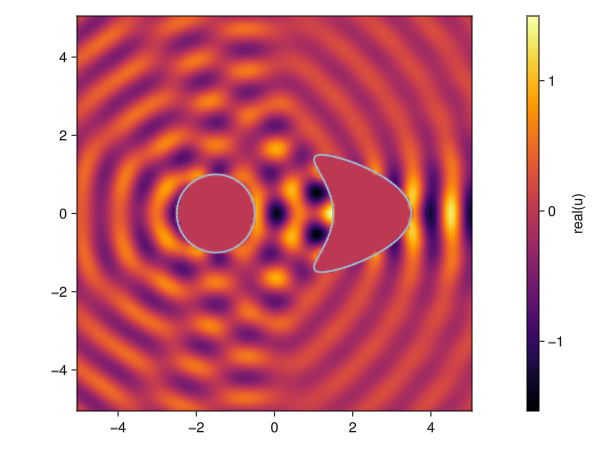

In [2]:
# TODO: add the description of the tutorial
using Inti
using LinearAlgebra
using StaticArrays

# Physical parameters
k = 2π
pde = Inti.Helmholtz(; dim = 2, k)

# Mesh generation
kite = Inti.parametric_curve(0.0, 1.0) do s
    return SVector(2.5, 0) +
           SVector(cos(2π * s[1]) + 0.65 * cos(4π * s[1]) - 0.65, 1.5 * sin(2π * s[1]))
end
circle = Inti.parametric_curve(0.0, 1.0) do s
    return SVector(-1.5, 0) + SVector(cos(2π * s[1]), sin(2π * s[1]))
end
Γ = kite ∪ circle
msh = Inti.meshgen(Γ; meshsize = 2π / k / 10)
Q = Inti.Quadrature(msh; qorder = 5)

# Operators
S, D = Inti.single_double_layer(;
    pde,
    target = Q,
    source = Q,
    compression = (method = :none,),
    correction = (method = :dim,),
)

# Solution
θ = 0
d = SVector(cos(θ), sin(θ))
v = map(Q) do q
    # normal derivative of e^{ik*d⃗⋅x}
    x, ν = q.coords, q.normal
    return -im * k * exp(im * k * dot(x, d)) * dot(d, ν)
end ## Neumann trace on boundary
u = (-I / 2 + D) \ (S * v) # Dirichlet trace on boundary
𝒮, 𝒟 = Inti.single_double_layer_potential(; pde, source = Q)
uₛ = x -> 𝒟[u](x) - 𝒮[v](x)

# Visualization
using Meshes
using GLMakie # or your favorite plotting backend for Makie
xx = yy = range(-5; stop = 5, length = 100)
U = map(uₛ, Iterators.product(xx, yy))
fig, ax, hm = heatmap(
    xx,
    yy,
    real(U);
    colormap = :inferno,
    interpolate = true,
    axis = (aspect = DataAspect(), xgridvisible = false, ygridvisible = false),
)
viz!(msh; segmentsize = 2)
Colorbar(fig[1, 2], hm; label = "real(u)")
fig

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*